# Randomized PCA & Virtual Centering

While **SVD** is the mathematical engine, **PCA (Principal Component Analysis)** is often the tool Data Scientists need.

Mathematically, **PCA is simply SVD performed on centered data** (where the mean of each column is subtracted).

### The "Big Data" Problem

If you have a massive **Sparse Matrix** (mostly zeros), subtracting the mean is dangerous.

* The mean  is usually non-zero (e.g., ).
* Calculating  turns every single zero into .
* **The matrix becomes DENSE.** A 1GB sparse matrix can instantly explode to 100GB, crashing your RAM.

### The Solution: Virtual Centering

`randomized-svd` implements a smart **Virtual Centering** technique. We perform operations on  implicitly, without ever creating the dense matrix in memory.


In [4]:
import time
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Import our new rPCA function
from randomized_svd import rpca

print("Libraries loaded.")


Libraries loaded.


## 1. The Concept: SVD vs. PCA (Why Centering Matters)

Let's visualize why you can't just use `rsvd` if you want PCA.
We generate a cloud of data points centered far away from the origin .

* **SVD** looks for the "strongest energy" from the origin.
* **PCA** looks for the "strongest variance" relative to the data center.

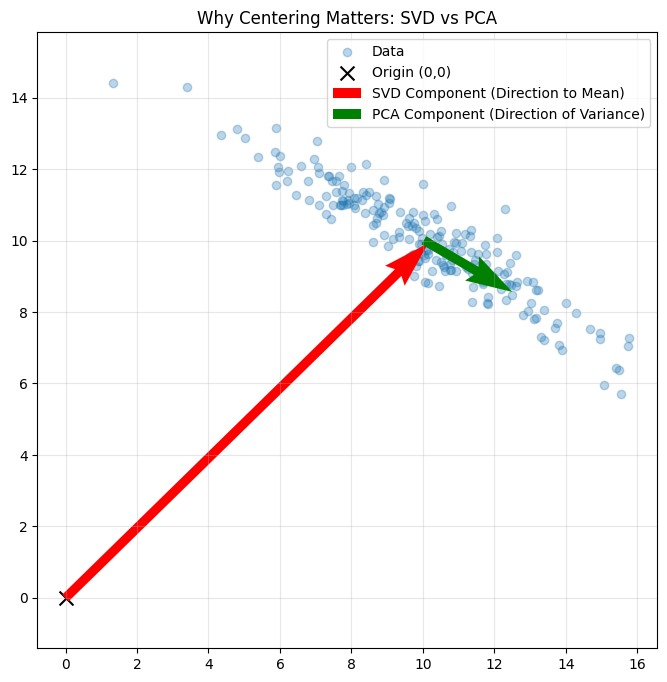

In [5]:
# 1. Generate Data centered at (10, 10)
np.random.seed(42)
mean_shift = np.array([10, 10])
# Create a stretched cloud
cloud = np.random.randn(200, 2) @ np.diag([3, 0.5]) 
# Rotate it slightly
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
X = (cloud @ R) + mean_shift

# 2. Compute Standard rSVD (No Centering)
from randomized_svd import rsvd
U_svd, S_svd, Vt_svd = rsvd(X, t=1)
# The first component of SVD points from (0,0) to the center of the cloud
vec_svd = Vt_svd[0] * S_svd[0] / np.sqrt(len(X)) 

# 3. Compute rPCA (With Virtual Centering)
U_pca, S_pca, Vt_pca = rpca(X, t=1)
# The first component of PCA follows the spread of the data
vec_pca = Vt_pca[0] * S_pca[0] / np.sqrt(len(X))

# --- Visualization ---
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label='Data')
plt.scatter([0], [0], c='black', marker='x', s=100, label='Origin (0,0)')

# Plot SVD Component
plt.quiver(0, 0, vec_svd[0], vec_svd[1], angles='xy', scale_units='xy', scale=1, 
           color='red', label='SVD Component (Direction to Mean)', width=0.015)

# Plot PCA Component (shifted to data mean for visualization)
data_mean = X.mean(axis=0)
plt.quiver(data_mean[0], data_mean[1], vec_pca[0], vec_pca[1], angles='xy', scale_units='xy', scale=1, 
           color='green', label='PCA Component (Direction of Variance)', width=0.015)

plt.title("Why Centering Matters: SVD vs PCA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()


## 2. The "Killer Feature": Sparse Matrix Support

Now let's simulate a scenario that would crash standard implementations without specialized solvers.

We create a **large sparse matrix**.

* **Format:** 
* **Density:**  (mostly zeros)

If we were to center this explicitly (), the memory usage would jump by **100x**.

In [6]:
N = 10000
density = 0.01

print(f"Generating {N}x{N} Sparse Matrix (Density: {density:.0%})...")
np.random.seed(42)
X_sparse = sp.rand(N, N, density=density, format='csr')

# Calculate memory usage
sparse_size_mb = (X_sparse.data.nbytes + X_sparse.indices.nbytes + X_sparse.indptr.nbytes) / 1e6
dense_size_mb = (N * N * 8) / 1e6  # 8 bytes per float64

print(f"💾 Memory required for Sparse storage:  ~{sparse_size_mb:.2f} MB")
print(f"💥 Memory required for Centering (Dense): ~{dense_size_mb:.2f} MB")
print(f"   -> Increase factor: {dense_size_mb / sparse_size_mb:.1f}x")

print("\nRunning rPCA with Virtual Centering...")
start_time = time.time()

# This works because rpca wraps X_sparse in a LinearOperator
# It NEVER creates the 800MB dense matrix.
U, S, Vt = rpca(X_sparse, t=50)

elapsed = time.time() - start_time
print(f"✅ Done in {elapsed:.2f} seconds.")
print(f"   Computed {len(S)} principal components.")
print(f"   Top singular value: {S[0, 0]:.4f}")


Generating 10000x10000 Sparse Matrix (Density: 1%)...
💾 Memory required for Sparse storage:  ~12.04 MB
💥 Memory required for Centering (Dense): ~800.00 MB
   -> Increase factor: 66.4x

Running rPCA with Virtual Centering...
✅ Done in 0.11 seconds.
   Computed 50 principal components.
   Top singular value: 8.5980


## 3. Correctness Verification

Finally, let's verify that our randomized implementation produces the same results (eigenvalues/singular values) as Scikit-Learn's implementation on a smaller dense dataset.

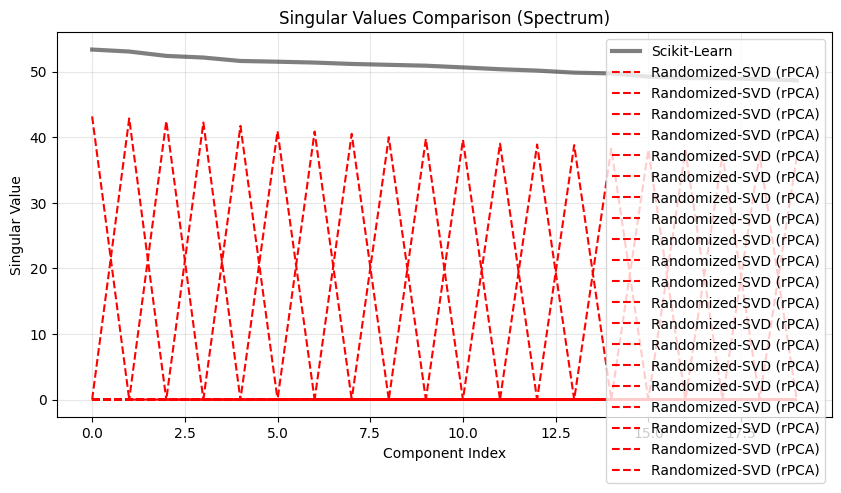

Relative Error vs Sklearn: 4.36e+00


In [7]:
# Generate smaller dense data for comparison
X_dense = np.random.randn(1000, 500) + 5 # Non-zero mean
k = 20

# 1. Scikit-Learn PCA
# Note: Sklearn uses "n_components"
sklearn_pca = PCA(n_components=k, svd_solver='randomized', random_state=42)
sklearn_pca.fit(X_dense)
s_sklearn = sklearn_pca.singular_values_

# 2. Our rPCA
# Note: We use "t" (target rank)
_, s_ours, _ = rpca(X_dense, t=k)

# Compare
plt.figure(figsize=(10, 5))
plt.plot(s_sklearn, 'k-', label='Scikit-Learn', linewidth=3, alpha=0.5)
plt.plot(s_ours, 'r--', label='Randomized-SVD (rPCA)')
plt.title('Singular Values Comparison (Spectrum)')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Numerical Check
error = np.linalg.norm(s_sklearn - s_ours) / np.linalg.norm(s_sklearn)
print(f"Relative Error vs Sklearn: {error:.2e}")
